In [1]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_datasets
from models.prototypical_segmentation import PrototypicalSegmentation
from training.prototypical_trainer import PrototypicalTrainer
from configs.results_utils import save_kshot_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Data Loading
train_dataset, val_dataset, test_dataset = get_datasets(Config)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Val samples:   {len(val_dataset)}")
print(f"✓ Test samples:  {len(test_dataset)}")

✓ Splits -> Train: 258, Val: 74, Test: 37
✓ Valid patients: 258/258
✓ Valid patients: 74/74
✓ Valid patients: 37/37
✓ Train samples: 25800
✓ Val samples:   7400
✓ Test samples:  3700


In [3]:
# CELL 3: Create Model + Load Pretrained Encoder
model = PrototypicalSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

load_model_weights(model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Loaded checkpoint: best_model.pth
✓ Model parameters: 24,433,669


In [4]:
# CELL 4: Sanity Check
trainer = PrototypicalTrainer(
    model=model,
    config=Config,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
)

# Test one episode
episode = trainer.sample_episode(train_dataset, k_shot=5, n_query=10)
print(f"✓ Support: {episode['support_images'].shape}")
print(f"✓ Query:   {episode['query_images'].shape}")

# Test prototype extraction
support_imgs = episode['support_images'].to(Config.DEVICE)
support_masks = episode['support_masks'].to(Config.DEVICE)
prototypes = model.compute_prototypes(support_imgs, support_masks)
print(f"✓ Extracted {len(prototypes)} prototypes, shape: {prototypes[0].shape}")

✓ Support: torch.Size([5, 2, 128, 128])
✓ Query:   torch.Size([10, 2, 128, 128])
✓ Extracted 4 prototypes, shape: torch.Size([512])


STARTING PROTOTYPICAL NETWORKS TRAINING
Starting Prototypical Networks training
Episodes: 1000, k-shot: 5, n-query: 10
Device: mps
Episode [100/1000] Loss: 0.1066
  Validation Loss: 0.1831
Episode [200/1000] Loss: 0.1131
  Validation Loss: 0.1908
Episode [300/1000] Loss: 0.1346
  Validation Loss: 0.1800
Episode [400/1000] Loss: 0.1700
  Validation Loss: 0.2431
Episode [500/1000] Loss: 0.1474
  Validation Loss: 0.2045
✓ Saved checkpoint: /Users/yuzheli/Desktop/Grad School/CS7150/Final Project/UNet-FewShot/checkpoints/prototypical_ep500.pth
Episode [600/1000] Loss: 0.0921
  Validation Loss: 0.2100
Episode [700/1000] Loss: 0.0895
  Validation Loss: 0.2049
Episode [800/1000] Loss: 0.1273
  Validation Loss: 0.2121
Episode [900/1000] Loss: 0.1247
  Validation Loss: 0.2535
Episode [1000/1000] Loss: 0.1234
  Validation Loss: 0.1920
✓ Saved checkpoint: /Users/yuzheli/Desktop/Grad School/CS7150/Final Project/UNet-FewShot/checkpoints/prototypical_ep1000.pth
✓ Training complete!


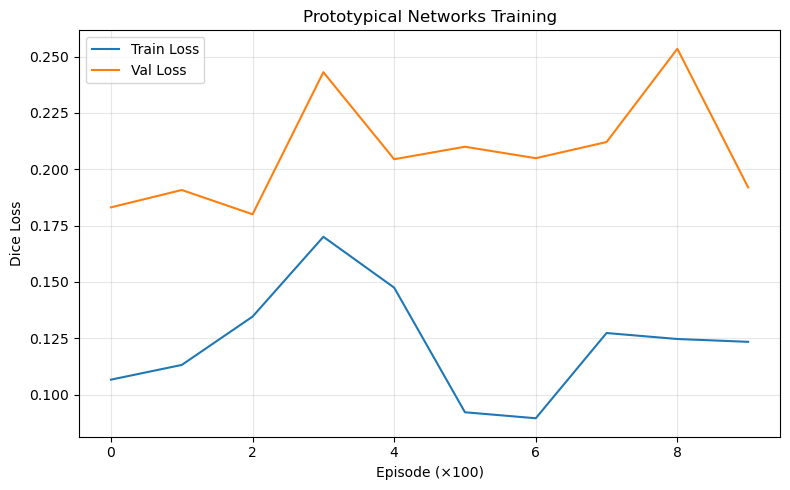

In [5]:
# CELL 5: Train Prototypical Networks
print("=" * 60)
print("STARTING PROTOTYPICAL NETWORKS TRAINING")
print("=" * 60)

history = trainer.train(
    num_episodes=1000,
    k_shot=5,
    n_query=Config.N_QUERY,
)

# Training Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Episode (×100)')
ax.set_ylabel('Dice Loss')
ax.set_title('Prototypical Networks Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'prototypical_training_curve.png'), dpi=150)
plt.show()

In [6]:
# CELL 6: Evaluate at Different k Values (Dice + HD95)
k_shot_results = trainer.evaluate_k_shot(
    k_values=Config.K_SHOT_VALUES,
    num_episodes=50,
    compute_hd95=True,
)

# Print summary
print(f"\n{'='*60}")
print("PROTOTYPICAL NETWORKS K-SHOT RESULTS")
print(f"{'='*60}")
for k in Config.K_SHOT_VALUES:
    r = k_shot_results[k]
    print(f"  k={k:>2}: Dice = {r['mean']:.4f} ± {r['std']:.4f}  |  "
          f"HD95 = {r['hd95_mean']:.2f} ± {r['hd95_std']:.2f} px")
print(f"{'='*60}")

save_kshot_results(k_shot_results, Config.RESULTS_DIR, 'prototypical_kshot_results.json')

Evaluating k=1:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating k=1: 100%|██████████| 50/50 [00:15<00:00,  3.21it/s]


k=1: DICE = 0.7986 ± 0.0523  |  HD95 = 1.89 ± 1.05 px


Evaluating k=5: 100%|██████████| 50/50 [00:20<00:00,  2.46it/s]


k=5: DICE = 0.7947 ± 0.0856  |  HD95 = 1.92 ± 1.04 px


Evaluating k=10: 100%|██████████| 50/50 [00:24<00:00,  2.01it/s]


k=10: DICE = 0.7970 ± 0.0612  |  HD95 = 1.97 ± 1.20 px


Evaluating k=20: 100%|██████████| 50/50 [00:36<00:00,  1.38it/s]

k=20: DICE = 0.8288 ± 0.0591  |  HD95 = 1.92 ± 1.21 px

PROTOTYPICAL NETWORKS K-SHOT RESULTS
  k= 1: Dice = 0.7986 ± 0.0523  |  HD95 = 1.89 ± 1.05 px
  k= 5: Dice = 0.7947 ± 0.0856  |  HD95 = 1.92 ± 1.04 px
  k=10: Dice = 0.7970 ± 0.0612  |  HD95 = 1.97 ± 1.20 px
  k=20: Dice = 0.8288 ± 0.0591  |  HD95 = 1.92 ± 1.21 px
✓ Saved to: /Users/yuzheli/Desktop/Grad School/CS7150/Final Project/UNet-FewShot/results/prototypical_kshot_results.json


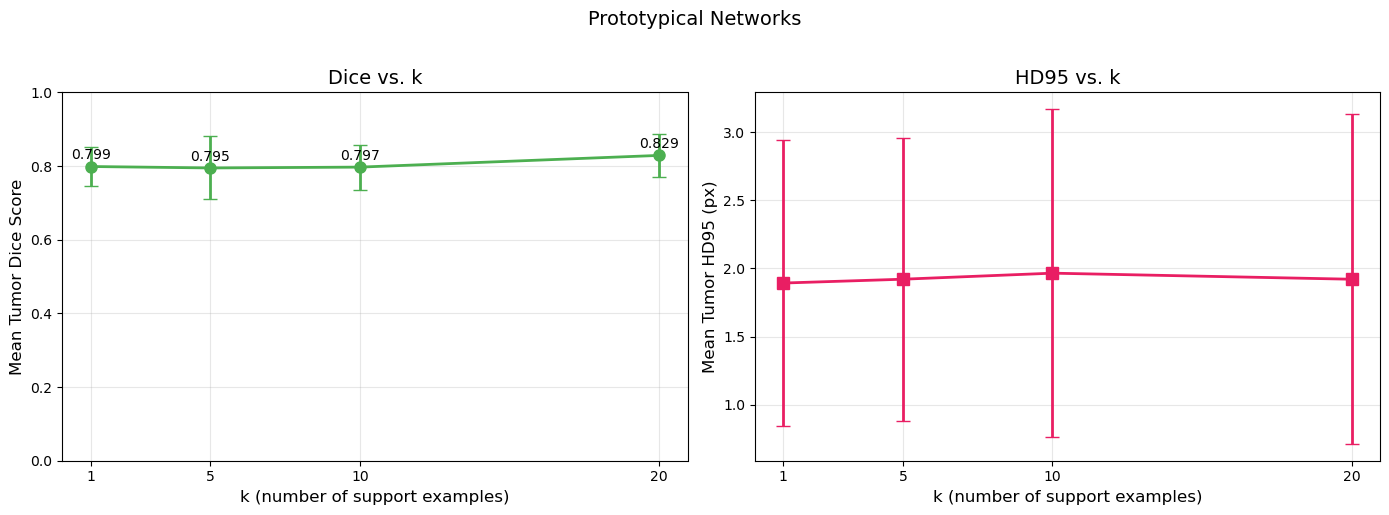

In [7]:
# CELL 7: Learning Curves (Dice + HD95)
k_values = Config.K_SHOT_VALUES
means = [k_shot_results[k]['mean'] for k in k_values]
stds = [k_shot_results[k]['std'] for k in k_values]
hd_means = [k_shot_results[k]['hd95_mean'] for k in k_values]
hd_stds = [k_shot_results[k]['hd95_std'] for k in k_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dice curve
ax1.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
             linewidth=2, markersize=8, color='#4CAF50')
ax1.set_xlabel('k (number of support examples)', fontsize=12)
ax1.set_ylabel('Mean Tumor Dice Score', fontsize=12)
ax1.set_title('Dice vs. k', fontsize=14)
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

for k, dice in zip(k_values, means):
    ax1.text(k, dice + 0.02, f'{dice:.3f}', ha='center', fontsize=10)

# HD95 curve
ax2.errorbar(k_values, hd_means, yerr=hd_stds, marker='s', capsize=5,
             linewidth=2, markersize=8, color='#E91E63')
ax2.set_xlabel('k (number of support examples)', fontsize=12)
ax2.set_ylabel('Mean Tumor HD95 (px)', fontsize=12)
ax2.set_title('HD95 vs. k', fontsize=14)
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)

plt.suptitle('Prototypical Networks', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'prototypical_kshot_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()